In [ ]:
import numpy as np
from optiland import optic
from optiland.materials import IdealMaterial

# Navarro wide-angle eye (Escudero-Sanz and Navarro, 1999) at 543 nm
eye = optic.Optic()

materials = {
    "cornea": IdealMaterial(1.3777),
    "aqueous_humor": IdealMaterial(1.3391),
    "lens": IdealMaterial(1.4222),
    "vitreous_humor": IdealMaterial(1.3377),
}

# Object at infinity
eye.surfaces.add(index=0, radius=np.inf, thickness=np.inf)

# Surface stack: (label, radius [mm], thickness to next [mm], conic, material)
navarro_surfaces = [
    ("Cornea anterior", 7.72, 0.55, -0.26, materials["cornea"]),
    ("Cornea posterior", 6.50, 3.05, 0.00, materials["aqueous_humor"]),
    ("Pupil stop", np.inf, 0.00, None, materials["aqueous_humor"]),
    ("Lens anterior", 10.20, 4.00, -3.1316, materials["lens"]),
    ("Lens posterior", -6.00, 16.3203, -1.00, materials["vitreous_humor"]),
    ("Retina", -12.00, 0.00, None, materials["vitreous_humor"]),
]



for i, (label, radius, thickness, conic, material) in enumerate(navarro_surfaces, start=1):
    surface_kwargs = {
        "index": i,
        "radius": radius,
        "thickness": thickness,
        "material": material,
        "is_stop": label == "Pupil stop",
    }
    if conic is not None:
        surface_kwargs["conic"] = conic
    eye.surfaces.add(**surface_kwargs)

eye.set_aperture(aperture_type="float_by_stop_size", value=3.0)

eye.fields.set_type(field_type="angle")
for angle_deg in [0, 15, 30, 45]:
    eye.fields.add(angle_deg)

eye.wavelengths.add(0.543)


In [ ]:
# Second eye model based on a real-subject geometry dataset
geometry = {
    "axial_length": 24.305,  # mm
    "cornea_thickness": 0.5615,  # mm
    "anterior_chamber_depth": 3.345,  # mm
    "lens_thickness": 3.17,  # mm
    "cornea_front_curvature": 7.6967,  # mm
    "cornea_front_asphericity": -0.2304,
    "cornea_back_curvature": 6.2343,  # mm
    "cornea_back_asphericity": -0.1444,
    "iris_radius": 0.5,  # mm
    "lens_front_curvature": 10.2,  # mm
    "lens_front_asphericity": -3.1316,
    "lens_back_curvature": -5.4537,  # mm
    "lens_back_asphericity": -4.1655,
    "retina_curvature": -11.3357,  # mm
    "retina_asphericity": -0.0631,
}

vitreous_depth = (
    geometry["axial_length"]
    - geometry["cornea_thickness"]
    - geometry["anterior_chamber_depth"]
    - geometry["lens_thickness"]
)

eye_subject = optic.Optic()
eye_subject.surfaces.add(index=0, radius=np.inf, thickness=np.inf)

subject_surfaces = [
    (
        "Cornea anterior",
        geometry["cornea_front_curvature"],
        geometry["cornea_thickness"],
        geometry["cornea_front_asphericity"],
        materials["cornea"],
    ),
    (
        "Cornea posterior",
        geometry["cornea_back_curvature"],
        geometry["anterior_chamber_depth"],
        geometry["cornea_back_asphericity"],
        materials["aqueous_humor"],
    ),
    ("Pupil stop", np.inf, 0.0, None, materials["aqueous_humor"]),
    (
        "Lens anterior",
        geometry["lens_front_curvature"],
        geometry["lens_thickness"],
        geometry["lens_front_asphericity"],
        materials["lens"],
    ),
    (
        "Lens posterior",
        geometry["lens_back_curvature"],
        vitreous_depth,
        geometry["lens_back_asphericity"],
        materials["vitreous_humor"],
    ),
    (
        "Retina",
        geometry["retina_curvature"],
        0.0,
        geometry["retina_asphericity"],
        materials["vitreous_humor"],
    ),
]

for i, (label, radius, thickness, conic, material) in enumerate(subject_surfaces, start=1):
    surface_kwargs = {
        "index": i,
        "radius": radius,
        "thickness": thickness,
        "material": material,
        "is_stop": label == "Pupil stop",
    }
    if conic is not None:
        surface_kwargs["conic"] = conic
    eye_subject.surfaces.add(**surface_kwargs)

# Use iris diameter from the dataset for the system stop aperture
eye_subject.set_aperture(
    aperture_type="float_by_stop_size",
    value=2.0 * geometry["iris_radius"],
)

eye_subject.fields.set_type(field_type="angle")
for angle_deg in [0, 15, 30, 45]:
    eye_subject.fields.add(angle_deg)

eye_subject.wavelengths.add(0.543)

print(f"Subject model vitreous depth: {vitreous_depth:.4f} mm")
print("Created eye_subject with real-subject geometry.")

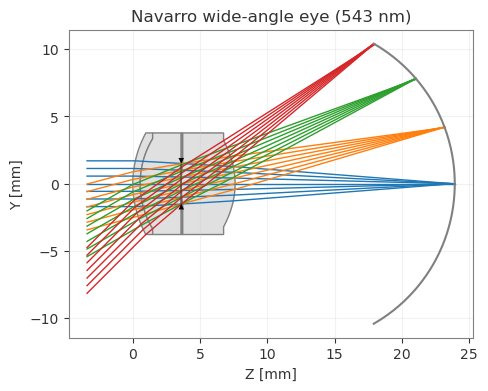

In [13]:
# Visualize the Navarro eye setup
fig, ax = eye.draw(
    fields="all",
    wavelengths="primary",
    num_rays=7,
    projection="YZ",
    title="Navarro wide-angle eye (543 nm)",
)


In [3]:
# Calculate Zernike coefficients for the central (on-axis) field
from optiland.wavefront import ZernikeOPD

zernike_opd = ZernikeOPD(
    eye,
    field=(0.0, 0.0),
    wavelength=0.543,
    num_rings=64,
    num_terms=15,
    zernike_type="noll",
)

def calculate_spherocylindrical_coefficients(zernike_coefficients):
    # Noll indices: defocus Z4, astigmatism Z5 and Z6
    defocus_index = 4
    astigmatism_indices = [5, 6]

    # Extract the coefficients (zero-based indexing in Python arrays)
    defocus_coefficient = zernike_coefficients[defocus_index - 1]
    astigmatism_coefficients = [zernike_coefficients[i - 1] for i in astigmatism_indices]

    return defocus_coefficient, astigmatism_coefficients

def zernike_to_diopters(
    zernike_coefficients,
    pupil_diameter_mm,
    wavelength_um=0.543,
    coefficient_unit="waves",
):
    """Convert Noll Z4/Z5/Z6 to power-vector diopters and sphero-cylinder.

    coefficient_unit can be: 'waves', 'microns', or 'meters'.
    """
    z4 = zernike_coefficients[3]  # defocus
    z5 = zernike_coefficients[4]  # oblique astigmatism
    z6 = zernike_coefficients[5]  # vertical/against-the-rule astigmatism

    if coefficient_unit == "waves":
        scale_to_m = wavelength_um * 1e-6
    elif coefficient_unit == "microns":
        scale_to_m = 1e-6
    elif coefficient_unit == "meters":
        scale_to_m = 1.0
    else:
        raise ValueError("coefficient_unit must be 'waves', 'microns', or 'meters'.")

    z4_m = z4 * scale_to_m
    z5_m = z5 * scale_to_m
    z6_m = z6 * scale_to_m

    pupil_radius_m = 0.5 * pupil_diameter_mm * 1e-3

    # Power-vector conversion (diopters) for normalized Noll Zernike polynomials
    M = -(4.0 * np.sqrt(3.0) * z4_m) / (pupil_radius_m**2)
    J45 = -(2.0 * np.sqrt(6.0) * z5_m) / (pupil_radius_m**2)
    J0 = -(2.0 * np.sqrt(6.0) * z6_m) / (pupil_radius_m**2)

    cylinder = -2.0 * np.sqrt(J0**2 + J45**2)
    axis_deg = (0.5 * np.degrees(np.arctan2(J45, J0))) % 180.0
    sphere = M - cylinder / 2.0

    return {
        "M": M,
        "J0": J0,
        "J45": J45,
        "sphere": sphere,
        "cylinder": cylinder,
        "axis_deg": axis_deg,
    }

# Keep your coefficient extraction
defocus_coefficient, astigmatism_coefficients = calculate_spherocylindrical_coefficients(
    zernike_opd.coeffs
)

# Convert to diopters (this eye model uses a 3.0 mm pupil diameter)
power = zernike_to_diopters(
    zernike_opd.coeffs,
    pupil_diameter_mm=3.0,
    wavelength_um=0.543,
    coefficient_unit="waves",
)

print(f"Defocus coefficient (Z4): {defocus_coefficient}")
print(f"Astigmatism coefficients (Z5, Z6): {astigmatism_coefficients}")
print("\nConverted to diopters:")
print(f"Sphere: {power['sphere']:.4f} D")
print(f"Cylinder: {power['cylinder']:.4f} D")
print(f"Axis: {power['axis_deg']:.2f} deg")

Defocus coefficient (Z4): 0.14887114297592335
Astigmatism coefficients (Z5, Z6): [np.float64(2.625000727389533e-15), np.float64(2.4256564383178885e-13)]

Converted to diopters:
Sphere: -0.2489 D
Cylinder: -0.0000 D
Axis: 90.31 deg


In [10]:
# make the eye more myopic by adding 1 mm to the axial length and re-calculate the sphere and cylinder powers
# Increase axial length by 1 mm (vitreous chamber depth)
eye.surfaces[4].thickness += 1.0

# Re-calculate Zernike coefficients and diopters for the modified eye
zernike_opd_modified = ZernikeOPD(
    eye,
    field=(0.0, 0.0),
    wavelength=0.543,
    num_rings=64,
    num_terms=15,
    zernike_type="noll",
)
defocus_coefficient_mod, astigmatism_coefficients_mod = calculate_spherocylindrical_coefficients(
    zernike_opd_modified.coeffs
)
power_mod = zernike_to_diopters(
    zernike_opd_modified.coeffs,
    pupil_diameter_mm=3.0,
    wavelength_um=0.543,
    coefficient_unit="waves",
)
print("\nAfter adding 1 mm to axial length:")
print(f"Defocus coefficient (Z4): {defocus_coefficient_mod}")
print(f"Astigmatism coefficients (Z5, Z6): {astigmatism_coefficients_mod}")
print("\nConverted to diopters:")
print(f"Sphere: {power_mod['sphere']:.4f} D")
print(f"Cylinder: {power_mod['cylinder']:.4f} D")
print(f"Axis: {power_mod['axis_deg']:.2f} deg")



After adding 1 mm to axial length:
Defocus coefficient (Z4): 0.14887114297592335
Astigmatism coefficients (Z5, Z6): [np.float64(2.625000727389533e-15), np.float64(2.4256564383178885e-13)]

Converted to diopters:
Sphere: -0.2489 D
Cylinder: -0.0000 D
Axis: 90.31 deg


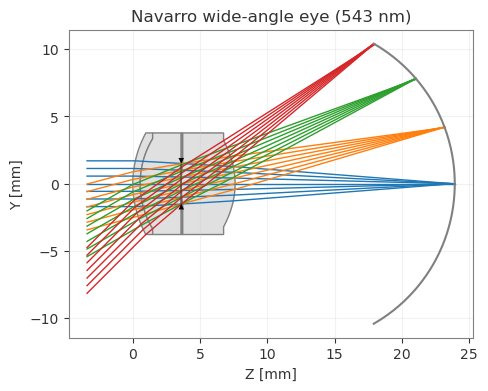

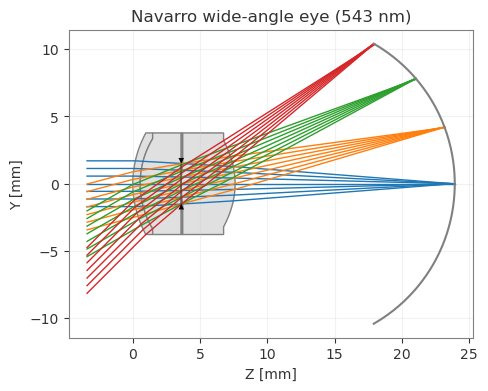

In [11]:
# Visualize the Navarro eye setup
fig, ax = eye.draw(
    fields="all",
    wavelengths="primary",
    num_rays=7,
    projection="YZ",
    title="Navarro wide-angle eye (543 nm)",
)
fig